In [120]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


train_df = pd.read_csv(
    "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"
)


In [122]:
print(train_df.shape)
print(test_df.shape)

(1460, 81)
(1459, 80)


In [123]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Cleaning

In [124]:
print("train_df:\n",train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("test_df:\n",test_df.isnull().sum()[train_df.isnull().sum() > 0])

train_df:
 LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
test_df:
 LotFrontage      227
Alley           1352
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
Electrical         0
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
dtype: int64


In [125]:
none_cols = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

train_df[none_cols] = train_df[none_cols].fillna("None")
test_df[none_cols] = test_df[none_cols].fillna("None")

In [126]:
#MasVnrArea missing value fill
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(0)

#GarageYrBlt
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(0)
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna(0)

#Electrical
train_df['Electrical'] = train_df['Electrical'].fillna(
    train_df['Electrical'].mode()[0]
)

#LotFrontage
lotFrontage_median = train_df['LotFrontage'].median()

train_df['LotFrontage'] = train_df['LotFrontage'].fillna(lotFrontage_median)
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(lotFrontage_median)

In [127]:
# Categorical columns → mode
cat_cols = [
    'MSZoning',
    'Utilities',
    'Exterior1st',
    'Exterior2nd',
    'KitchenQual',
    'Functional',
    'SaleType'
]

for col in cat_cols:
    test_df[col] = test_df[col].fillna(train_df[col].mode()[0])

In [128]:
num_cols = [
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFullBath',
    'BsmtHalfBath',
    'GarageCars',
    'GarageArea'
]

for col in num_cols:
    test_df[col] = test_df[col].fillna(train_df[col].median())

In [129]:
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [130]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())  

0
0


In [131]:
cat_cols = train_df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print(train_df[col].value_counts())


MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley
Alley
None    1369
Grvl      50
Pave      41
Name: count, dtype: int64

LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDO

In [132]:
num_cols = train_df.select_dtypes(include=np.number).columns

print(num_cols.tolist())

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [133]:
num_cols_without_target = train_df.select_dtypes(include=np.number).columns.drop(["SalePrice", "Id"])
num_cols_without_target

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

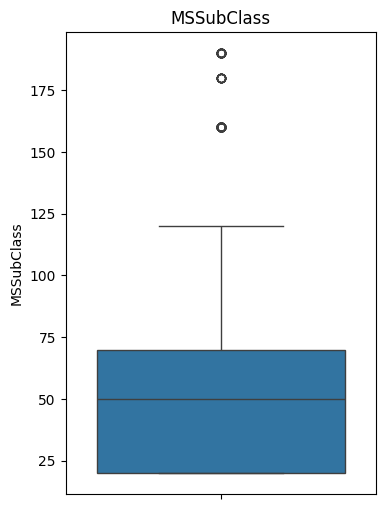

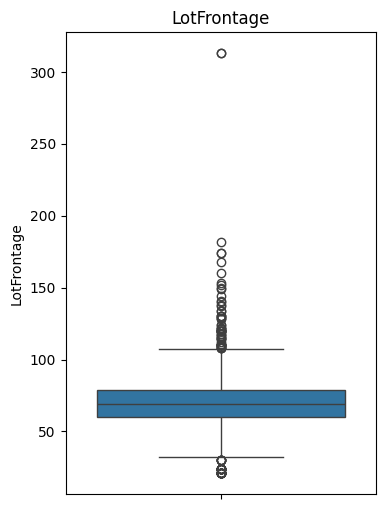

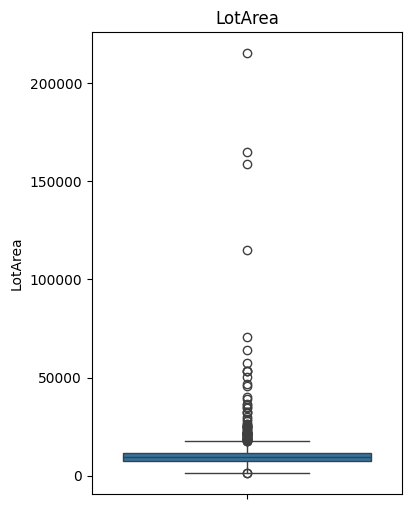

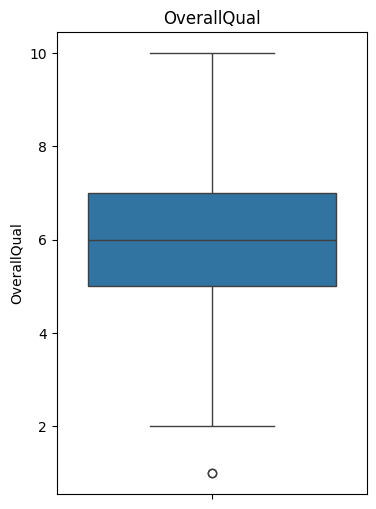

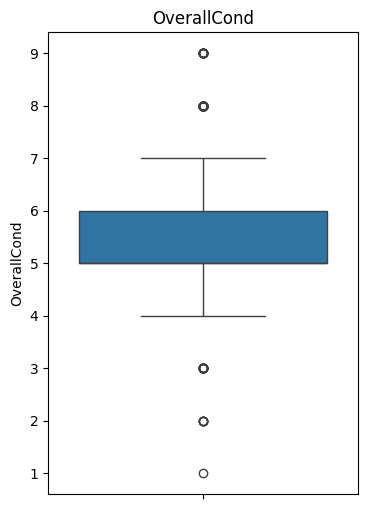

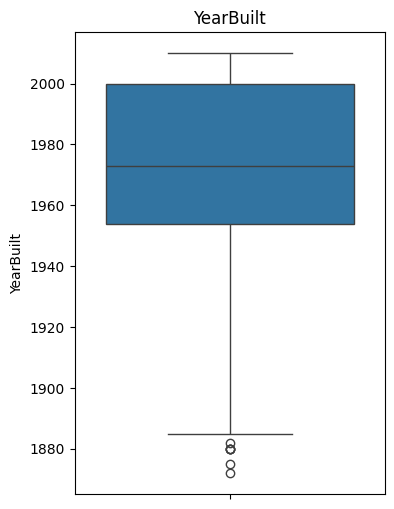

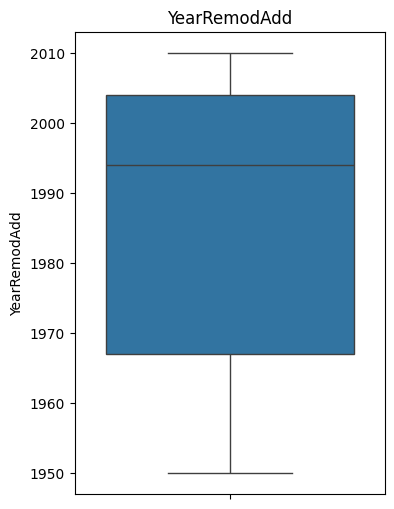

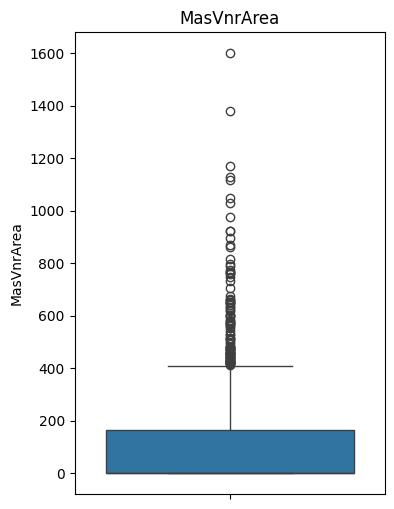

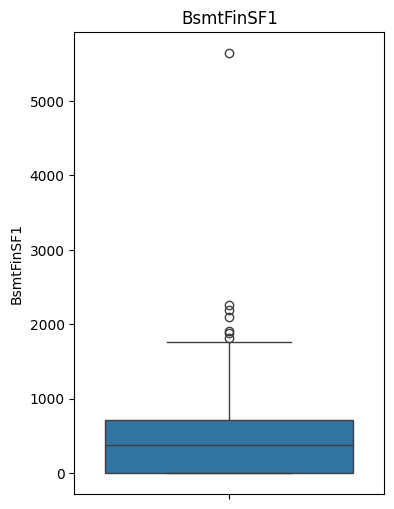

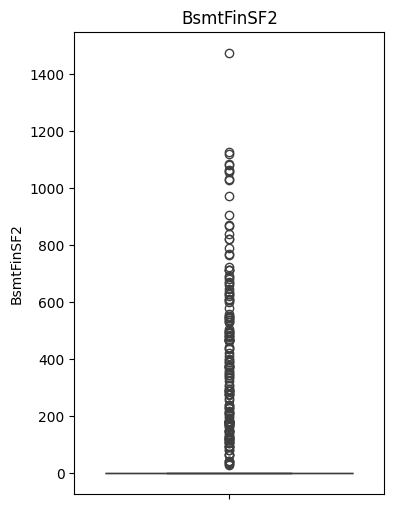

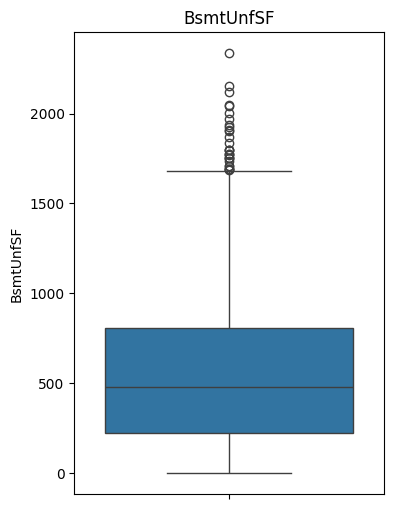

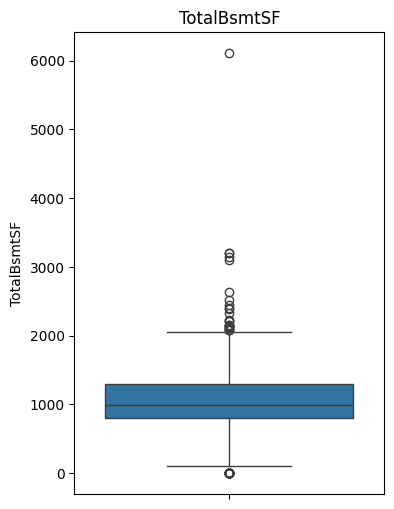

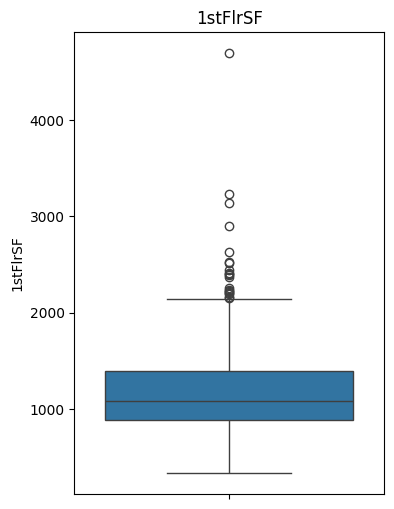

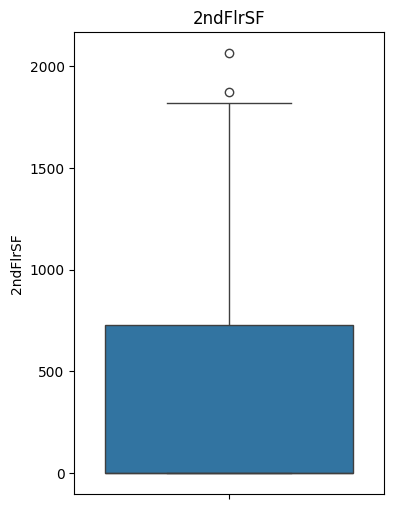

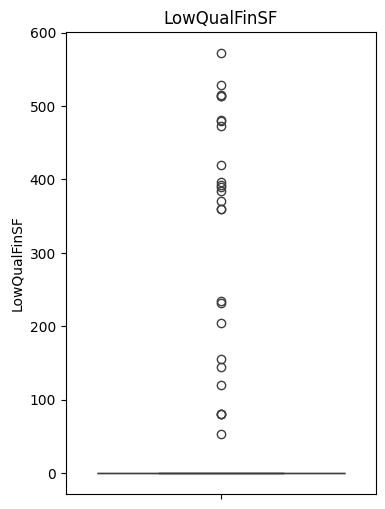

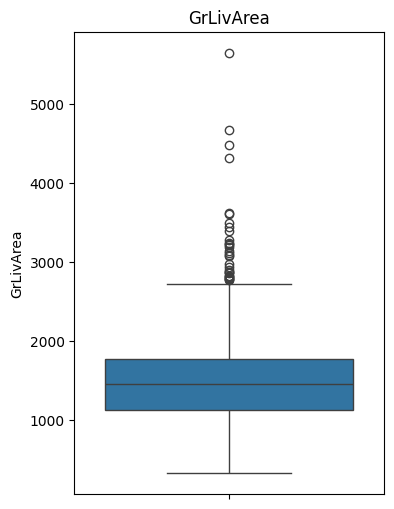

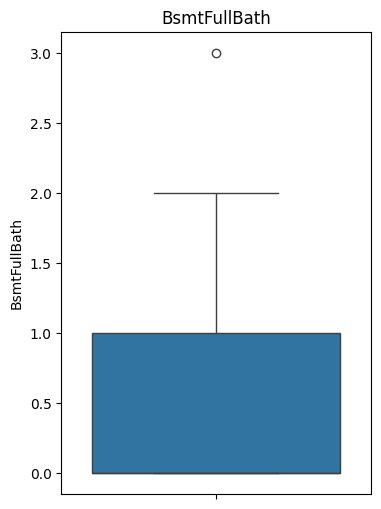

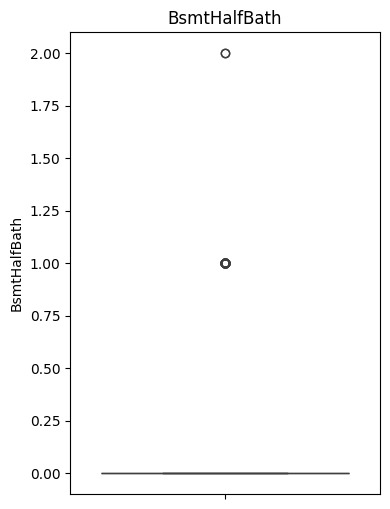

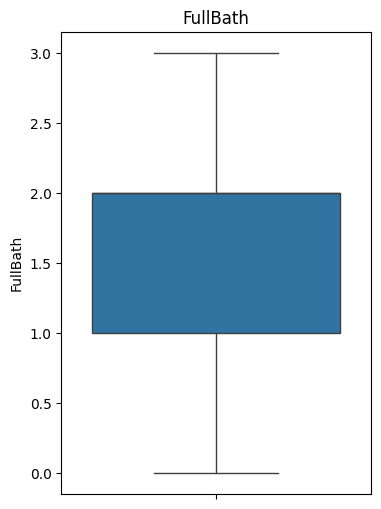

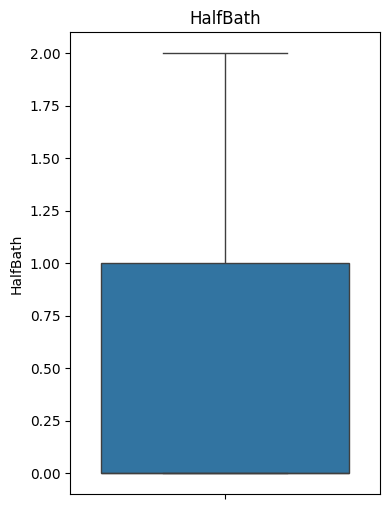

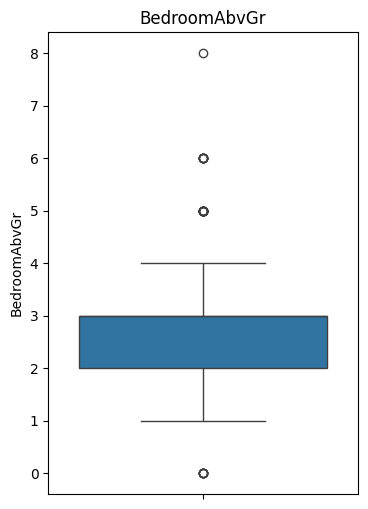

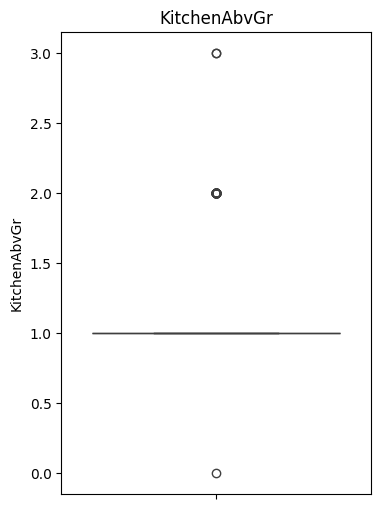

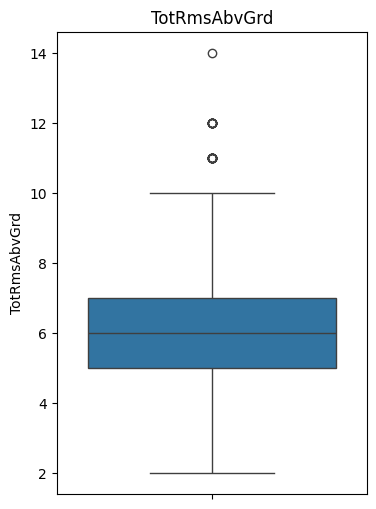

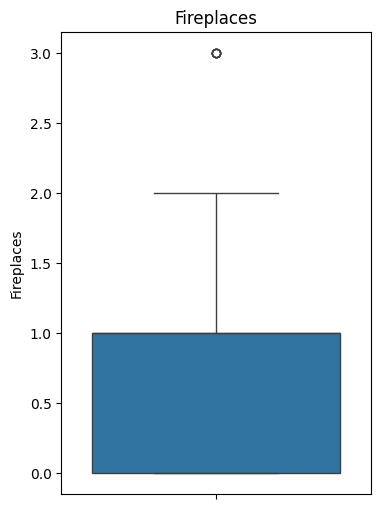

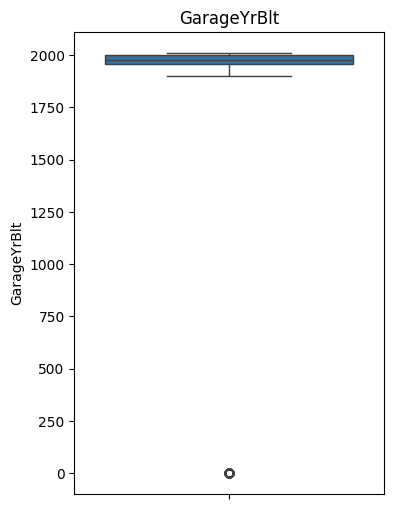

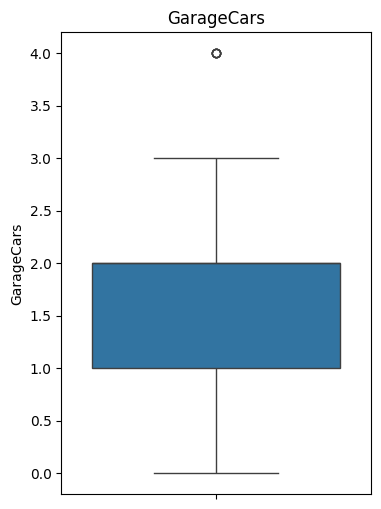

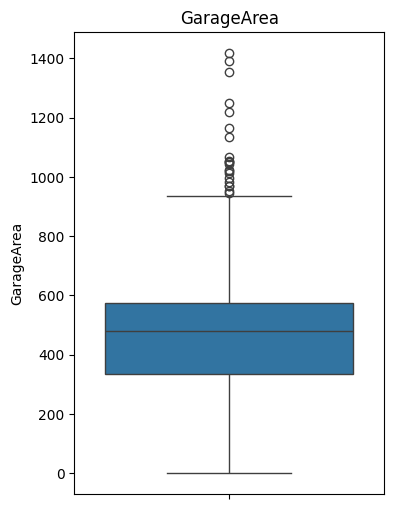

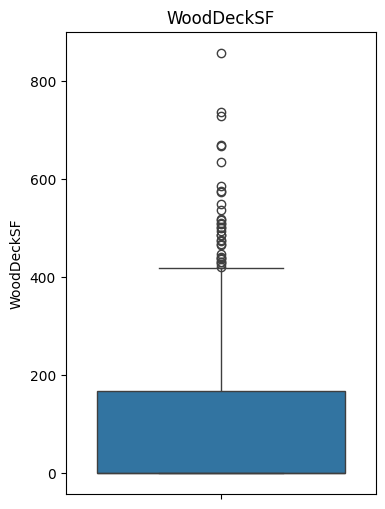

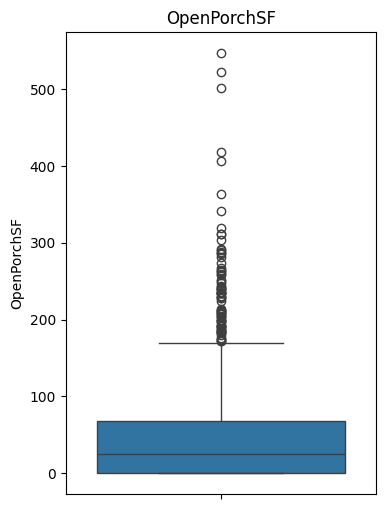

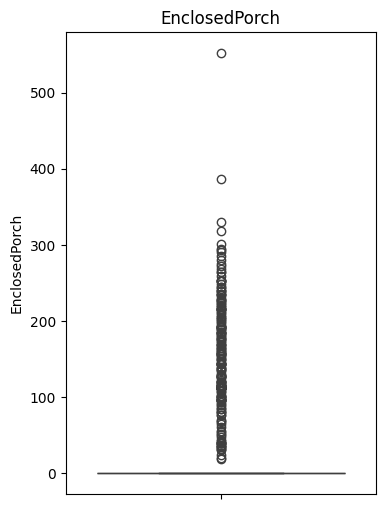

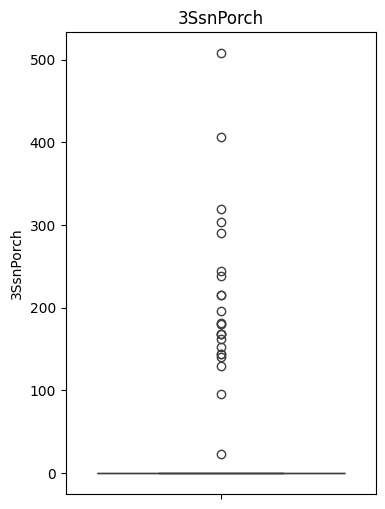

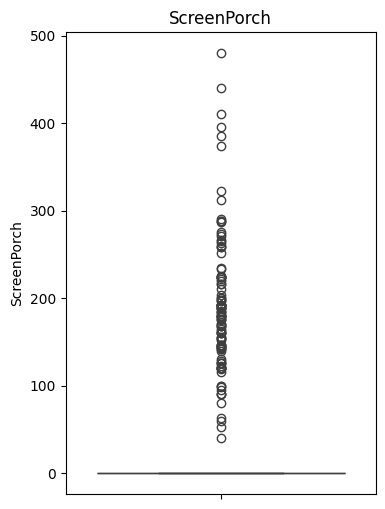

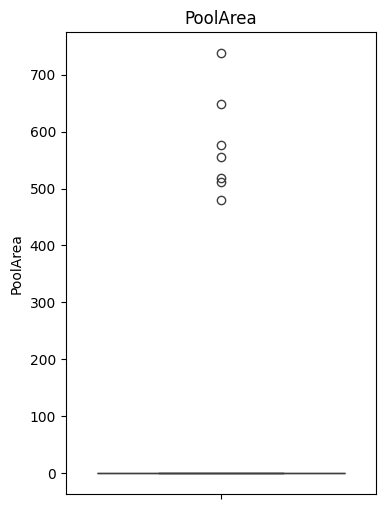

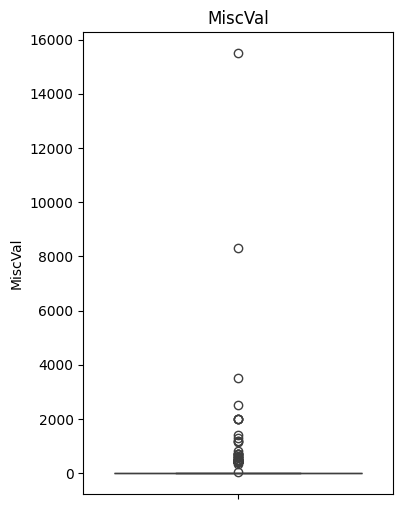

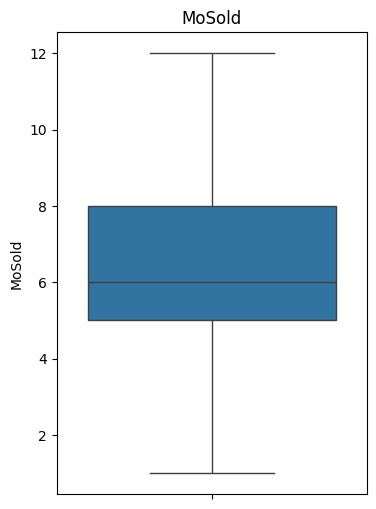

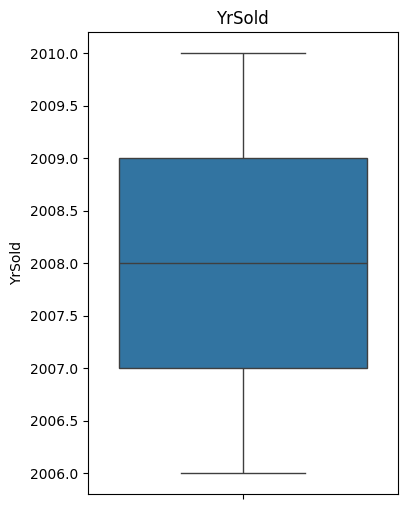

In [134]:
for col in num_cols_without_target:
    plt.figure(figsize=(4, 6))
    sns.boxplot(train_df[col].dropna())
    plt.title(f"{col}")
    plt.show()


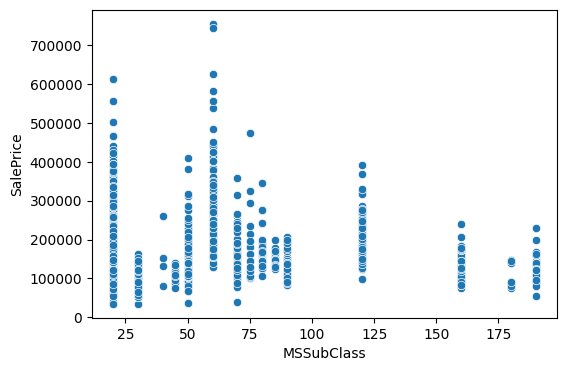

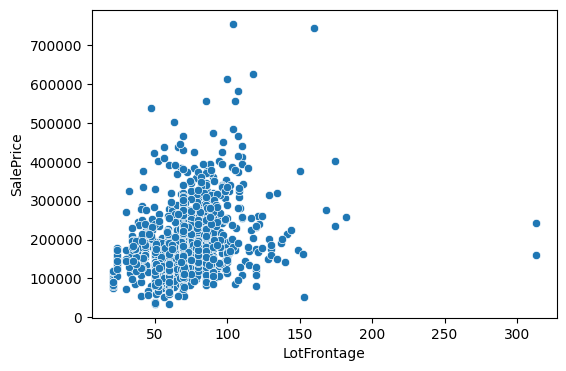

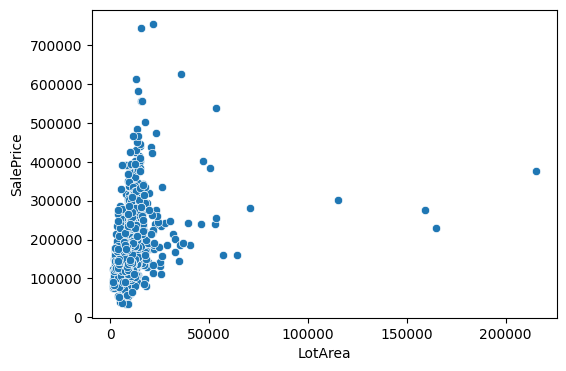

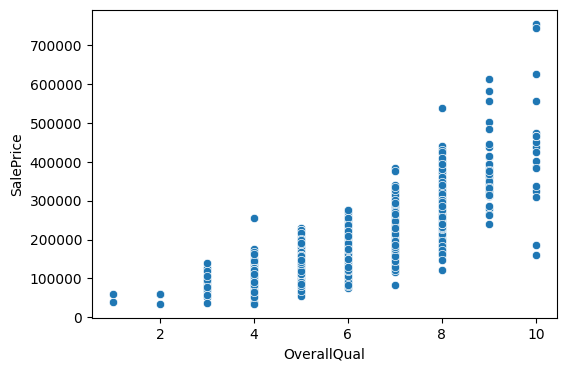

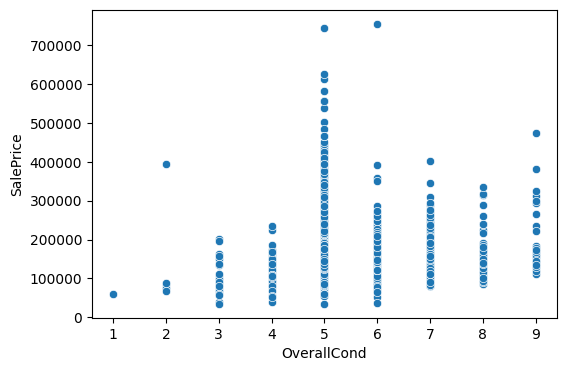

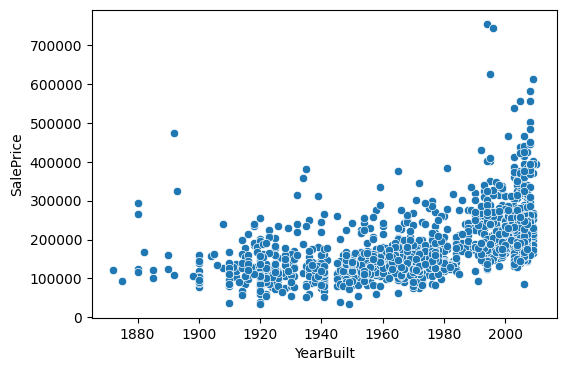

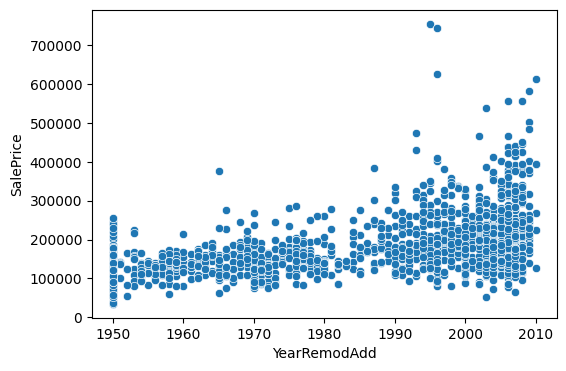

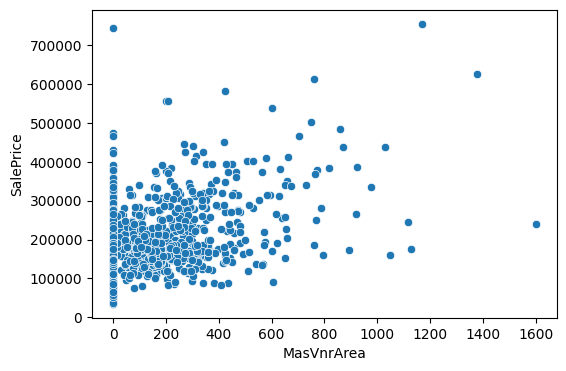

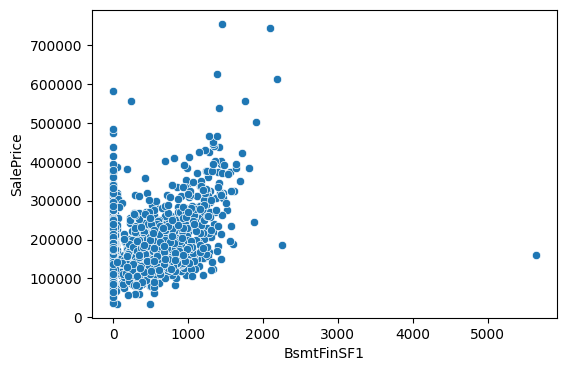

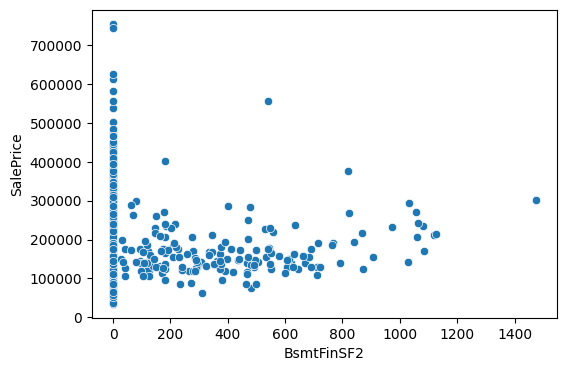

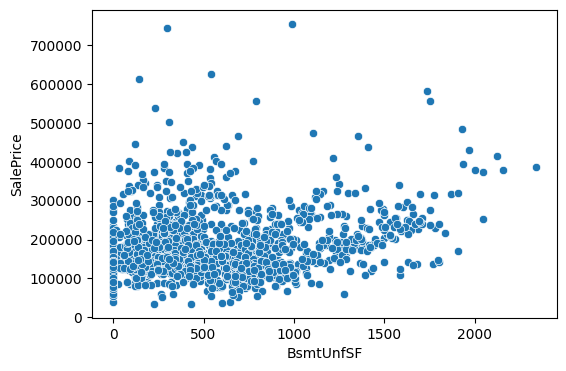

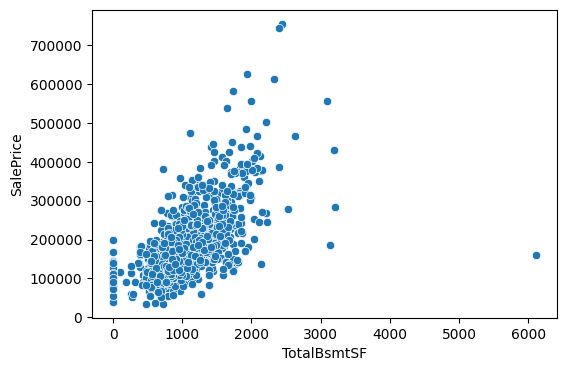

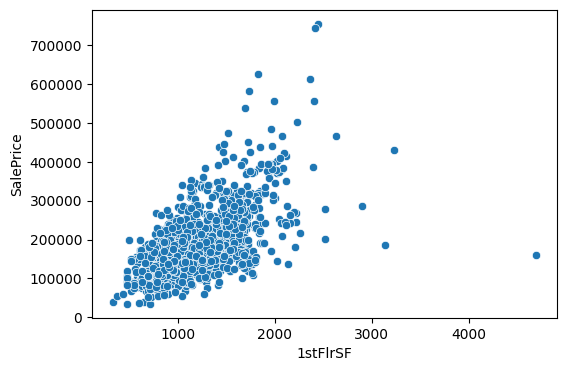

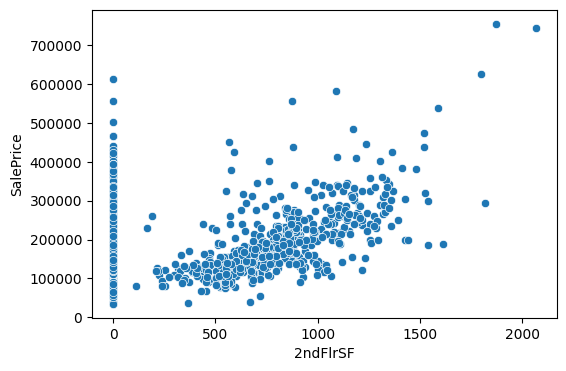

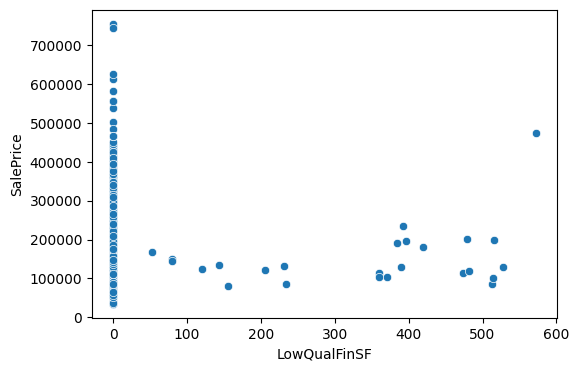

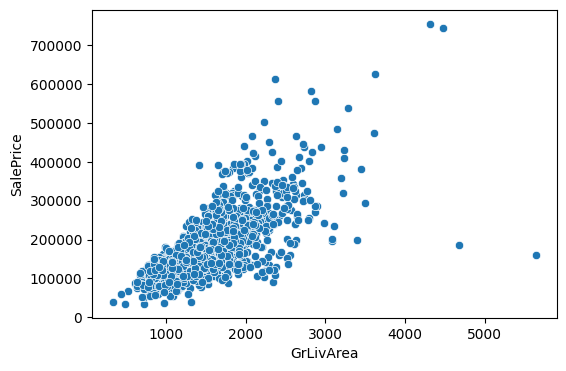

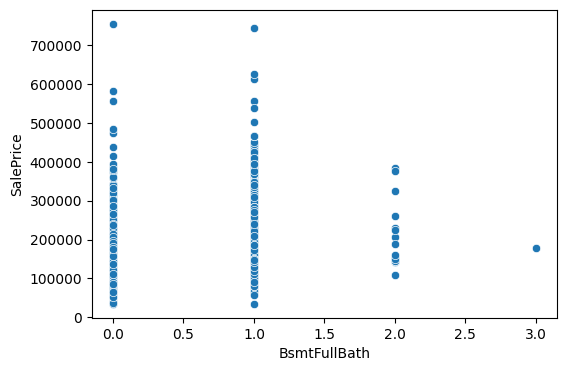

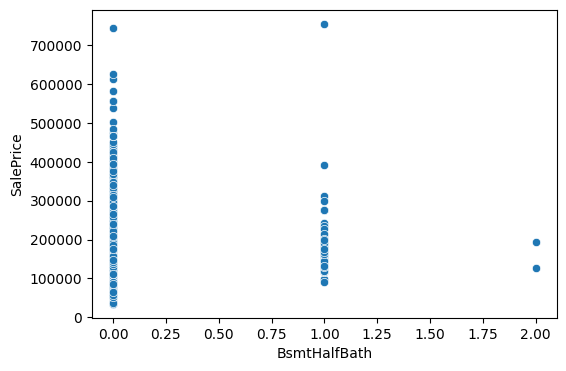

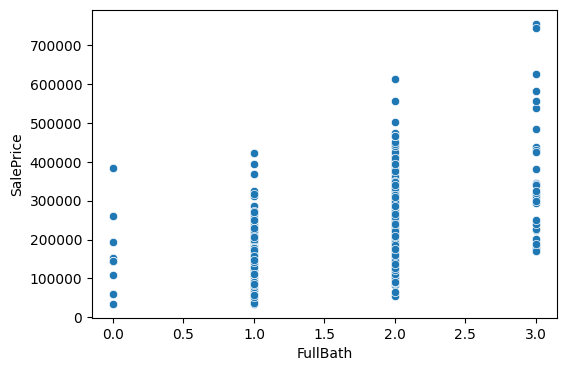

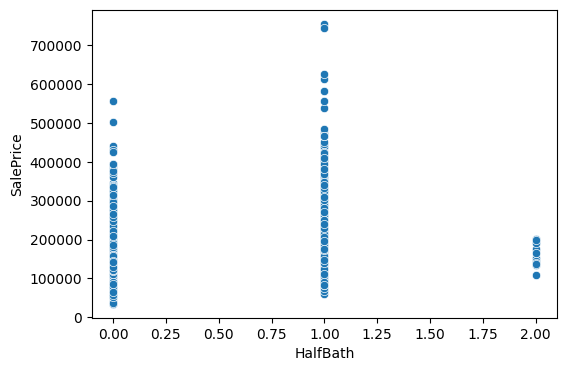

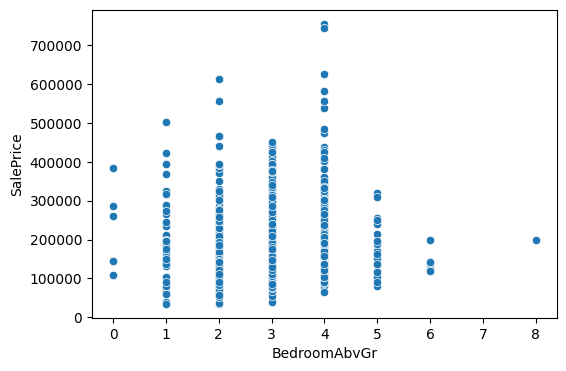

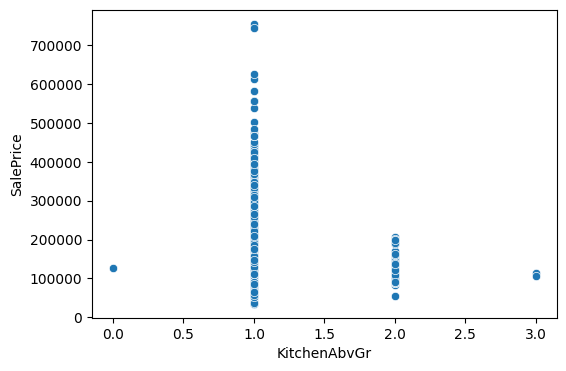

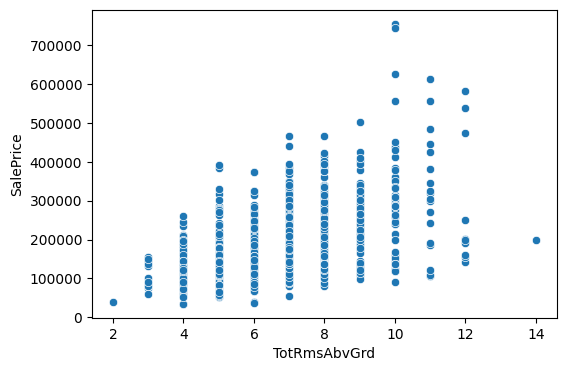

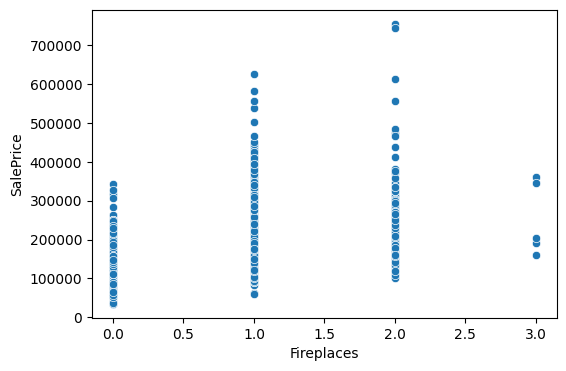

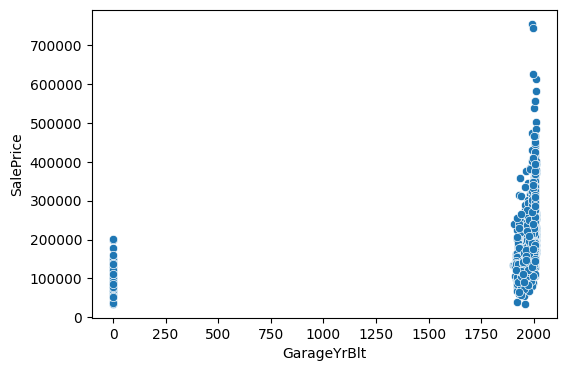

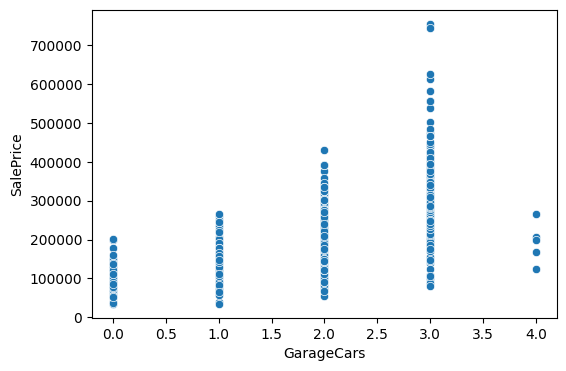

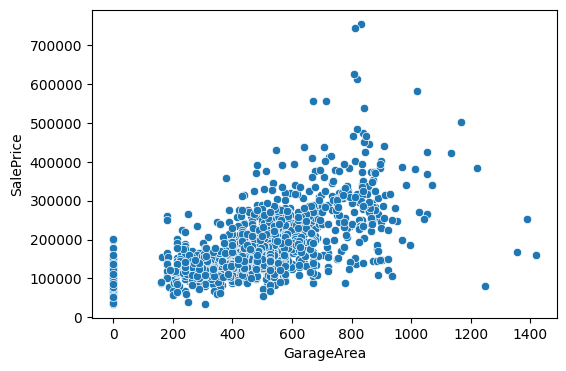

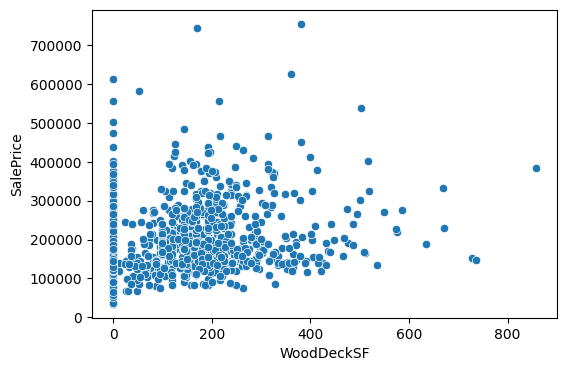

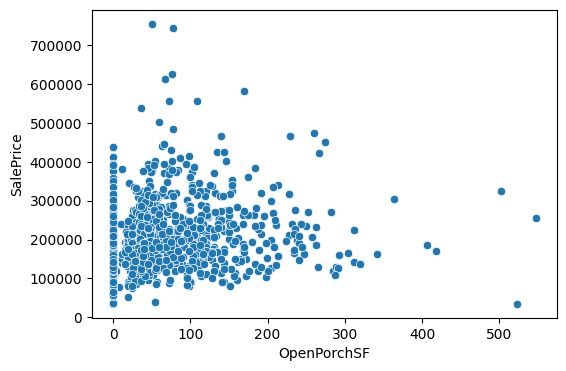

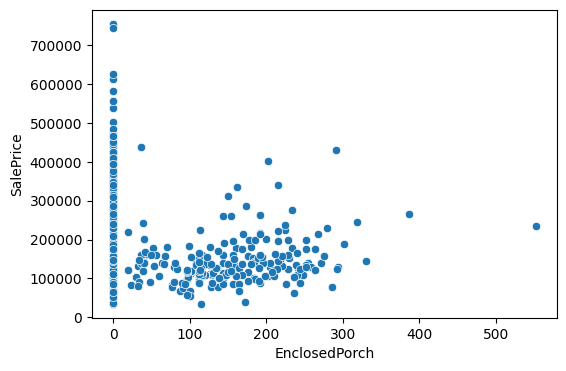

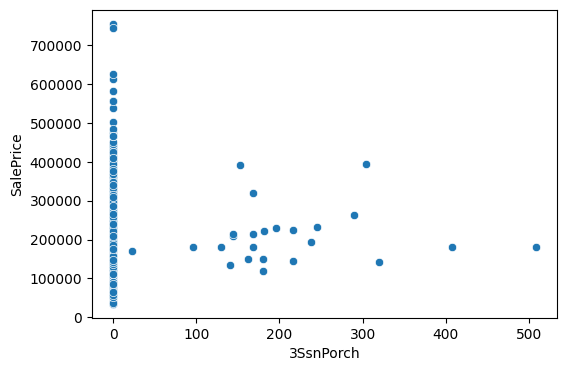

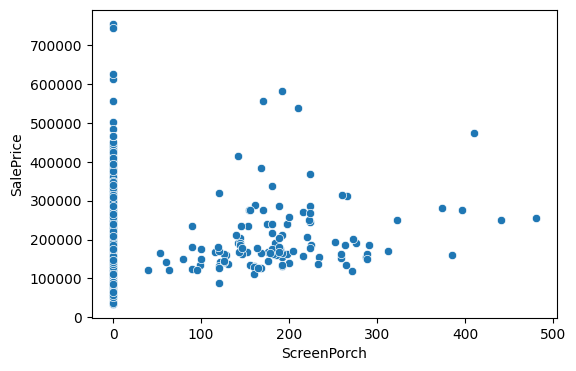

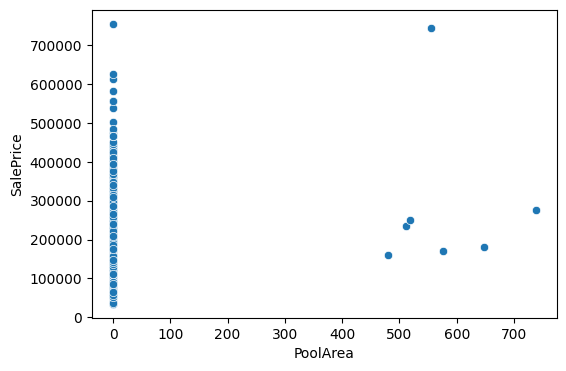

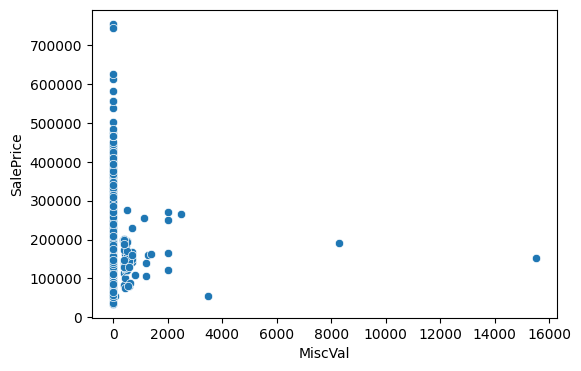

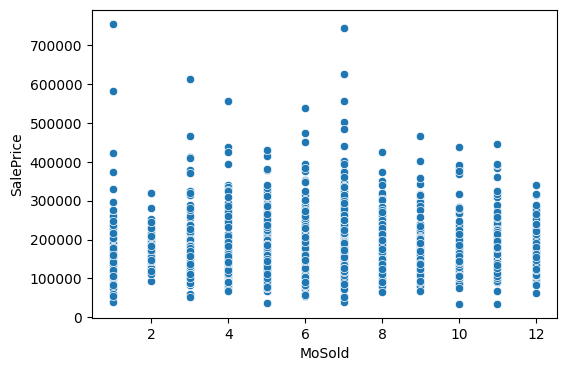

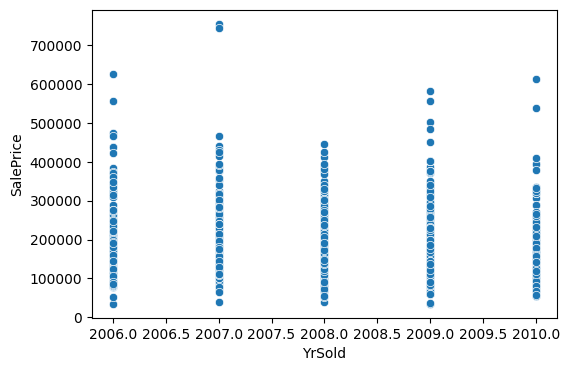

In [135]:
for col in num_cols_without_target:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=train_df[col], y=train_df['SalePrice'])
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.show()

In [136]:
#Coorelation


corr = train_df.select_dtypes(include=np.number).corr()['SalePrice'].sort_values(
    ascending=False
)

print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

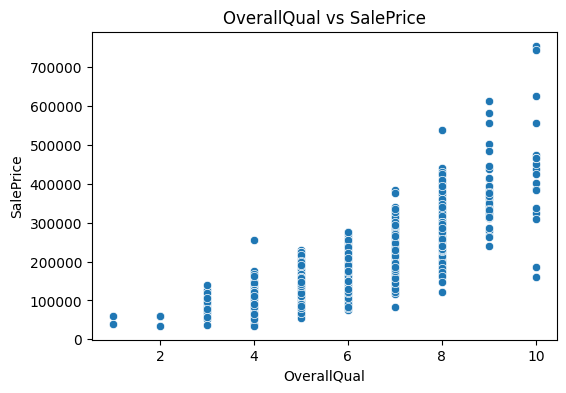

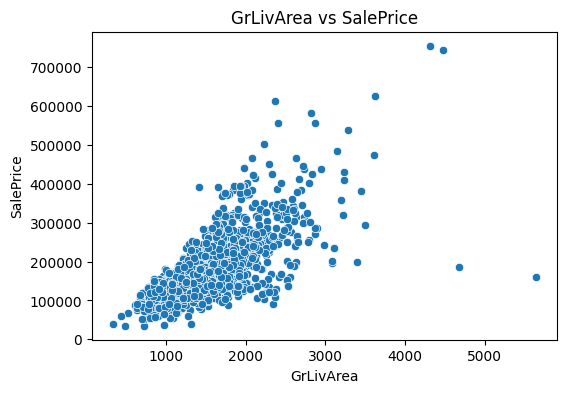

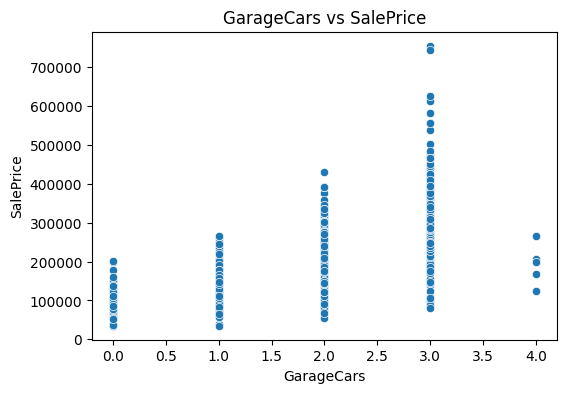

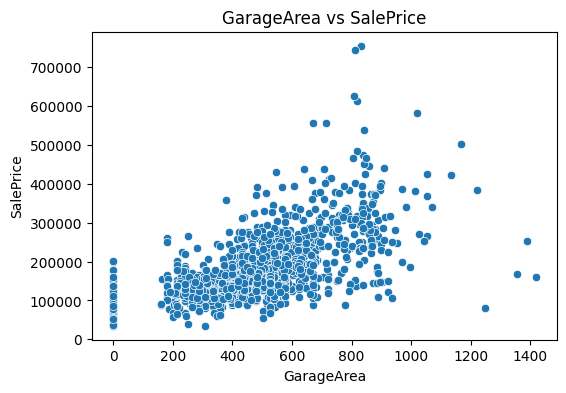

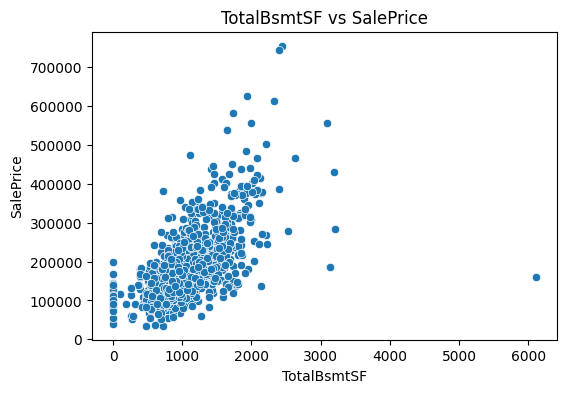

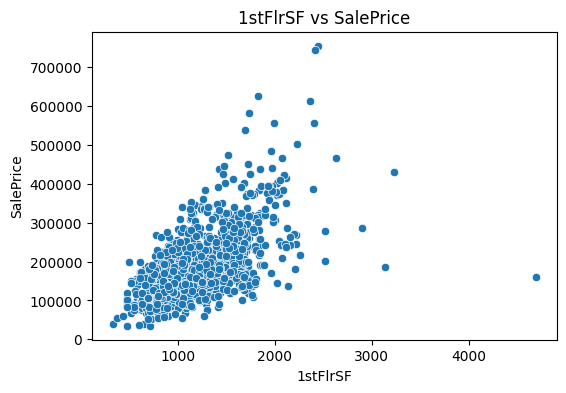

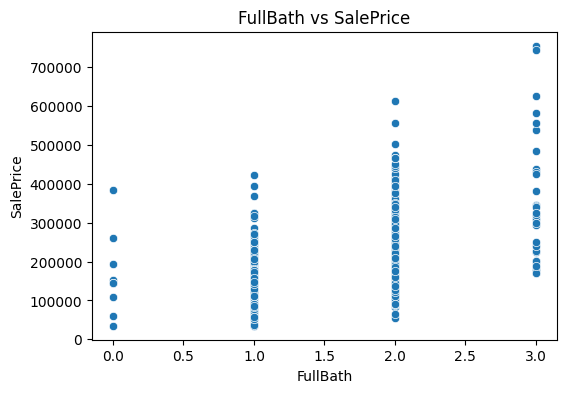

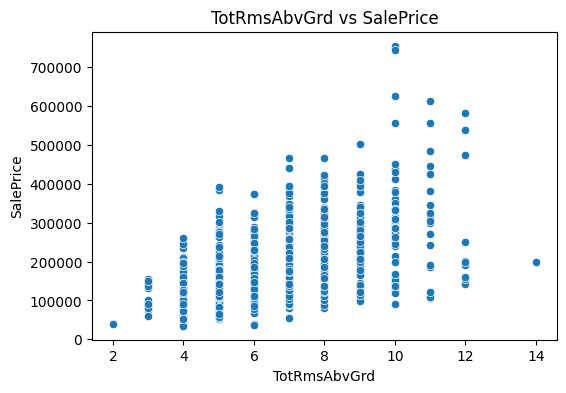

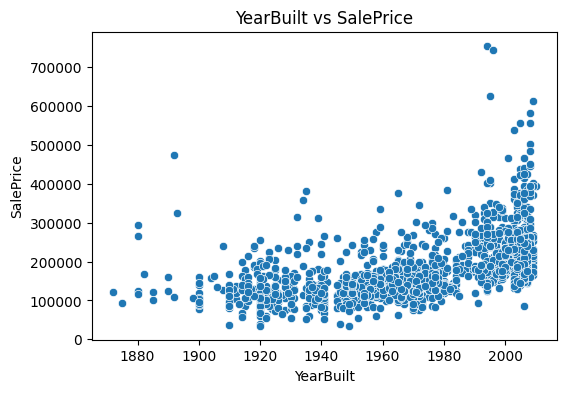

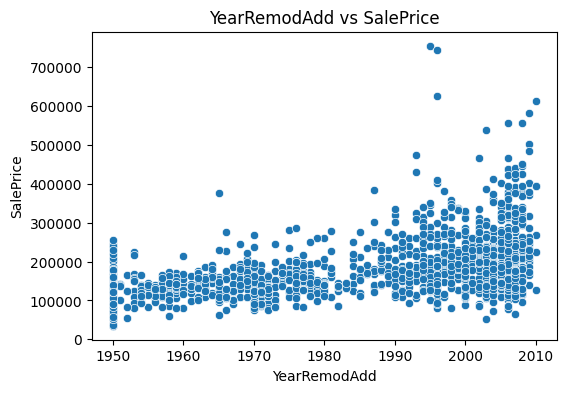

In [137]:
top_cols = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    'YearRemodAdd'
]

for col in top_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=train_df, x=col, y='SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.show()

In [138]:
print(
    train_df[
        (train_df['GrLivArea'] > 4000) &
        (train_df['SalePrice'] < 300000)
    ][['Id', 'GrLivArea', 'SalePrice']]
)

print(
    train_df[
        train_df['TotalBsmtSF'] > 5000
    ][['Id', 'TotalBsmtSF', 'SalePrice']]
)

print(
    train_df[
        train_df['1stFlrSF'] > 4000
    ][['Id', '1stFlrSF', 'SalePrice']]
)

        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000
        Id  TotalBsmtSF  SalePrice
1298  1299         6110     160000
        Id  1stFlrSF  SalePrice
1298  1299      4692     160000


In [139]:
train_df = train_df[~train_df['Id'].isin([524, 1299])].copy()

In [140]:
print(train_df[train_df['Id'].isin([524, 1299])])

Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice]
Index: []

[0 rows x 81 columns]


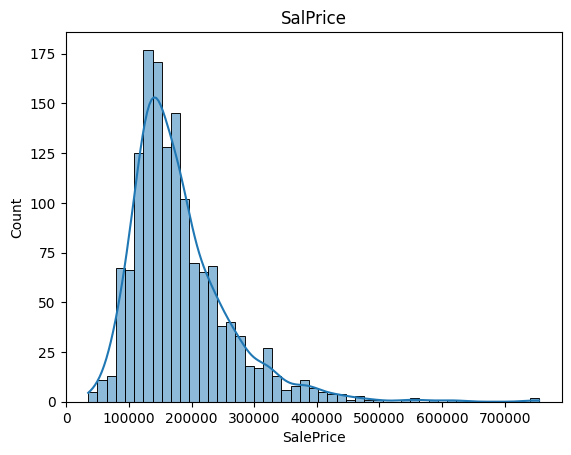

In [141]:
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('SalPrice')
plt.show()

Skewness: 1.8812964895244009
Log skewness: 0.12157976050304879


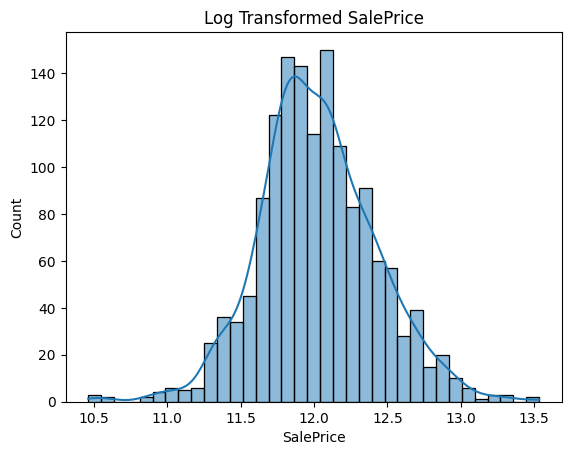

In [142]:
print("Skewness:", train_df['SalePrice'].skew())

log_saleprice = np.log1p(train_df['SalePrice'])
print("Log skewness:", log_saleprice.skew())


sns.histplot(log_saleprice, kde=True)
plt.title('Log Transformed SalePrice')
plt.show()

# Feature Engineering

In [143]:
y = np.log1p(train_df['SalePrice'])

X = train_df.drop('SalePrice', axis=1)

X_test = test_df.copy()

In [144]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

print("Numerical:", len(num_cols))
print("Categorial:", len(cat_cols))

Numerical: 37
Categorial: 43


In [145]:
skewed_cols = X[num_cols].skew().sort_values(ascending=False)
print(skewed_cols)    

MiscVal          24.460085
PoolArea         15.948945
LotArea          12.573925
3SsnPorch        10.297106
LowQualFinSF      9.004955
KitchenAbvGr      4.484883
BsmtFinSF2        4.251925
ScreenPorch       4.118929
BsmtHalfBath      4.100114
EnclosedPorch     3.087164
MasVnrArea        2.696329
OpenPorchSF       2.339829
LotFrontage       1.720857
WoodDeckSF        1.545805
MSSubClass        1.407011
GrLivArea         1.010992
BsmtUnfSF         0.920903
1stFlrSF          0.887637
2ndFlrSF          0.812957
BsmtFinSF1        0.764789
OverallCond       0.691035
HalfBath          0.680051
TotRmsAbvGrd      0.660502
Fireplaces        0.632060
BsmtFullBath      0.590358
TotalBsmtSF       0.511703
MoSold            0.215432
BedroomAbvGr      0.212325
OverallQual       0.200786
GarageArea        0.131748
YrSold            0.095420
FullBath          0.031271
Id                0.000165
GarageCars       -0.342377
YearRemodAdd     -0.501838
YearBuilt        -0.612295
GarageYrBlt      -3.866380
d

In [146]:
skewed_cols = X[num_cols].skew().sort_values(ascending=False)

skewed_features = skewed_cols[
    abs(skewed_cols) > 0.75 
].index

print("Number of skewed features:", len(skewed_features))
print(skewed_features)

Number of skewed features: 21
Index(['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF',
       'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath',
       'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage',
       'WoodDeckSF', 'MSSubClass', 'GrLivArea', 'BsmtUnfSF', '1stFlrSF',
       '2ndFlrSF', 'BsmtFinSF1', 'GarageYrBlt'],
      dtype='object')


In [161]:
for col in skewed_features:
    X[col] = np.log1p(X[col])
    X_test[col] = np.log1p(X_test[col])

In [162]:
print(X[skewed_features].skew().sort_values(ascending=False))

PoolArea         15.508048
3SsnPorch         7.608916
LowQualFinSF      7.294760
MiscVal           5.013014
BsmtHalfBath      3.857636
ScreenPorch       3.110646
BsmtFinSF2        2.423582
EnclosedPorch     2.045937
MasVnrArea        0.392922
2ndFlrSF          0.277292
WoodDeckSF        0.088257
MSSubClass       -0.037529
1stFlrSF         -0.196858
OpenPorchSF      -0.200631
GrLivArea        -0.298632
BsmtFinSF1       -0.769972
LotArea          -0.936336
LotFrontage      -1.747161
BsmtUnfSF        -3.072240
GarageYrBlt      -3.884567
KitchenAbvGr    -19.393912
dtype: float64


# Data Preprocessing

In [165]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorial columns
cat_cols = X.select_dtypes(include='object').columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)
X_test_encoded = preprocessor.transform(X_test)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)



Before encoding: (1458, 80)
After encoding: (1458, 302)


In [166]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X train: (1166, 302)
X_val: (292, 302)
y_train: (1166,)
y_val: (292,)


In [167]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

model = Ridge(alpha=10)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("Validation RMSE:", rmse)

Validation RMSE: 0.13668841608926235


In [169]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print("Random Forest Validation RMSE:", rmse_rf)

Random Forest Validation RMSE: 0.1443043412816305


In [173]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

model_gb = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=15,
    loss='huber',
    random_state=42
)

model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_val)

rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_gb))

print("Gradient Boosting Validation RMSE:", rmse_gb)

Gradient Boosting Validation RMSE: 0.12283405448743726


In [174]:
print("Ridge RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)
print("Gradient Boosting:", rmse_gb)

Ridge RMSE: 0.13668841608926235
Random Forest RMSE: 0.1443043412816305
Gradient Boosting: 0.12283405448743726


In [178]:
params = [
    (500, 0.05),
    (1000, 0.03),
    (1500, 0.02),
    (2000, 0.015)
]


for n_est, lr in params:
    model = GradientBoostingRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=3,
        min_samples_leaf=15,
        loss='huber',
        random_state=42
    )


    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    score = np.sqrt(mean_squared_error(y_val, pred))


    print(
        f"n_estimators={n_est}",
        f"learning_rate={lr} -> RMSE={score:.6f}"
    )

n_estimators=500 learning_rate=0.05 -> RMSE=0.122460
n_estimators=1000 learning_rate=0.03 -> RMSE=0.122834
n_estimators=1500 learning_rate=0.02 -> RMSE=0.123033
n_estimators=2000 learning_rate=0.015 -> RMSE=0.122996


In [179]:
from sklearn.model_selection import KFold, cross_val_score

best_gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=15,
    loss='huber',
    random_state=42
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = np.sqrt(
    -cross_val_score(
        best_gb,
        X_encoded,
        y,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
)


print("Fold RMSE:", cv_scores)
print("Mean CV RMSE:", cv_scores.mean())
print("Std CV RMSE:", cv_scores.std())

Fold RMSE: [0.1224598  0.10889056 0.1300246  0.12898462 0.10722065]
Mean CV RMSE: 0.11951604547558363
Std CV RMSE: 0.009724474539629177


In [180]:
best_gb.fit(X_encoded, y)

test_pred_log = best_gb.predict(X_test_encoded)

y = np.log1p(train_df['SalePrice'])

test_pred = np.expm1(test_pred_log)

print(test_pred[:10])

[186258.5873801  226786.10531564 291412.98633901 318624.51851756
 338080.58551547 278883.90872799 292536.8147023  271893.78757362
 349390.0330798  186992.99125032]


In [181]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_pred
})

submission.to_csv('submission.csv', index=False)

print(submission.head())
print(submission.shape)

     Id      SalePrice
0  1461  186258.587380
1  1462  226786.105316
2  1463  291412.986339
3  1464  318624.518518
4  1465  338080.585515
(1459, 2)


In [183]:
submission.head(10)

,Id,SalePrice
0,1461,186258.587380
1,1462,226786.105316
2,1463,291412.986339
3,1464,318624.518518
4,1465,338080.585515
5,1466,278883.908728
6,1467,292536.814702
7,1468,271893.787574
8,1469,349390.033080
9,1470,186992.991250


In [193]:
submission.to_csv('submission.csv', index=False)